## GeoAI Flood Digital Twin

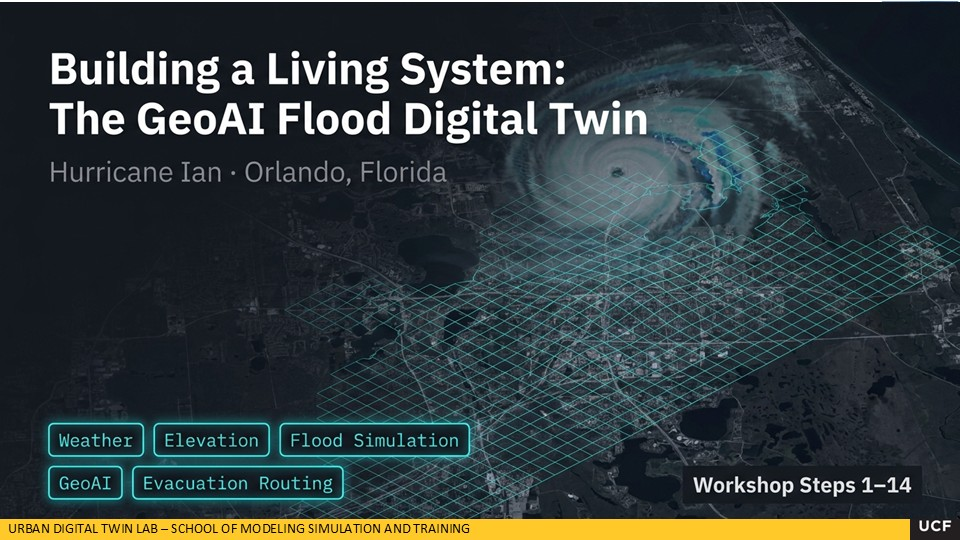

In this workshop, our GeoAI Flood Digital Twin for Orlando involves:

1.  **Physical Entity:** The city of Orlando, its terrain, weather, and population.
2.  **Data Acquisition:** Gathering real-time and historical data (weather, elevation, population).
3.  **Simulation/Modeling:** Using physics-based models (flood simulation) and AI models (flood classification) to predict conditions.
4.  **Analytics & Decision Support:** Analyzing risk, identifying hotspots, and recommending evacuation routes to shelters.
5.  **Feedback & Replay:** Allowing interactive exploration of scenarios (e.g., the Hurricane Ian replay slider) to understand impacts and inform decisions.


<div style="background:linear-gradient(135deg,#0b1f33,#146c94);padding:22px;border-radius:14px;color:white">
<h1 style="margin:0">GeoAI Flood Digital Twin Workshop</h1>
<p style="font-size:16px;margin:8px 0 0 0">Hands-on exercise using Hurricane Ian weather, real elevation, GeoAI flood prediction, and evacuation routing.</p>
</div>

**Goal:** Build a compact GeoAI flood digital twin for Orlando, Florida using Open-Meteo historical weather, USGS 3DEP DEM, terrain-aware flood simulation, Random Forest GeoAI prediction, risk mapping, shelter selection, OpenStreetMap routing, and replay sliders.
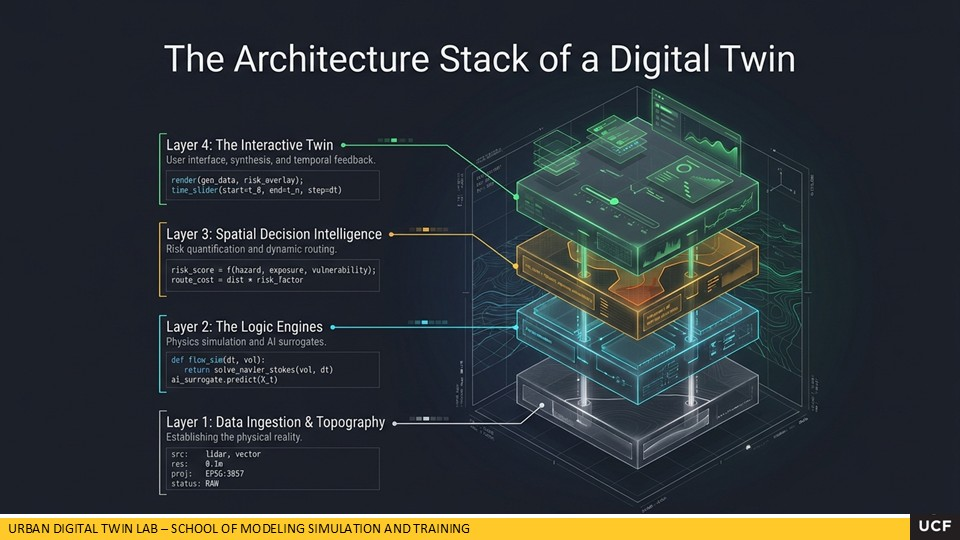


## 1 · Setup

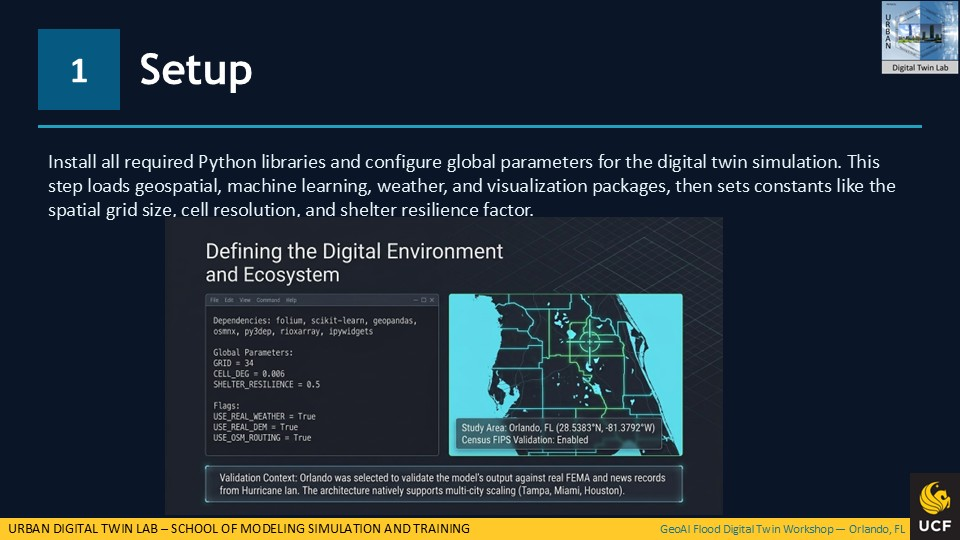

Run this once. In Colab, the install may take a few minutes. Also note that the Census API call and USGS DEM download can take 20-60 seconds each.



In [ ]:
%pip install folium scikit-learn shapely geopandas branca ipywidgets osmnx networkx openmeteo-requests requests-cache retry-requests py3dep xarray rioxarray rasterio scipy --quiet

In [ ]:
import os, math, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium import FeatureGroup, LayerControl
import geopandas as gpd
from shapely.geometry import Polygon
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
warnings.filterwarnings("ignore")
np.random.seed(42)

USE_REAL_WEATHER = True
USE_REAL_DEM = True
USE_OSM_ROUTING = True
GRID = 34
CELL_DEG = 0.006
MILES_PER_METER = 0.000621371
SHELTER_RESILIENCE = 0.5   # shelters tolerate 50% more flood
# Enable ipywidgets in Colab
try:
    from google.colab import output as _colab_output
    _colab_output.enable_custom_widget_manager()
except ImportError:
    pass

print("✅ Libraries loaded")

✅ Libraries loaded


## 2 · Study Area
Orlando, Florida. Ian made landfall as a Cat 4 hurricane on Sep 28, 2022, then tracked inland — Orlando received 10+ inches of rain and sustained gusts above 80 mph. This is a real, well-documented event you can validate against news footage, FEMA reports, and county records. Picking a real city + real storm means every prediction the model makes can be sanity-checked against what actually happened.

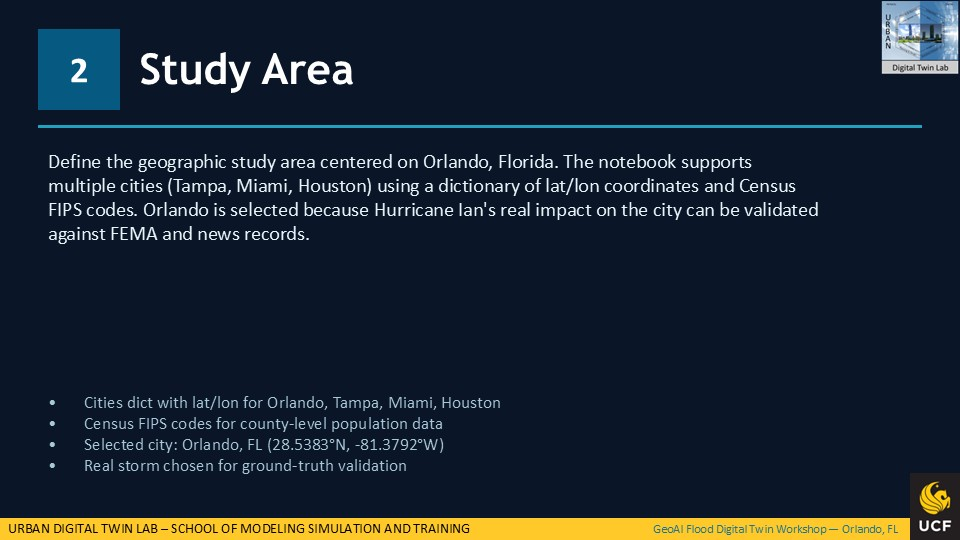

In [ ]:
CITIES = {
    "Orlando, Florida": {"lat": 28.5383, "lon": -81.3792},
    "Tampa, Florida":   {"lat": 27.9506, "lon": -82.4572},
    "Miami, Florida":   {"lat": 25.7617, "lon": -80.1918},
    "Houston, Texas":   {"lat": 29.7604, "lon": -95.3698},
}

CENSUS_FIPS = {
    "Orlando, Florida": {"state": "12", "county": "095"}, # Orange County
    "Tampa, Florida":   {"state": "12", "county": "057"}, # Hillsborough County
    "Miami, Florida":   {"state": "12", "county": "086"}, # Miami-Dade County
    "Houston, Texas":   {"state": "48", "county": "201"}, # Harris County
}

SELECTED_CITY = "Orlando, Florida"
LAT = CITIES[SELECTED_CITY]["lat"]
LON = CITIES[SELECTED_CITY]["lon"]

print(f"Study area: {SELECTED_CITY}")
print(f"Center: {LAT:.4f}, {LON:.4f}")

Study area: Orlando, Florida
Center: 28.5383, -81.3792


## 3 · Real Weather: Hurricane Ian 2022 from Open-Meteo
Uses the Open-Meteo archive endpoint.

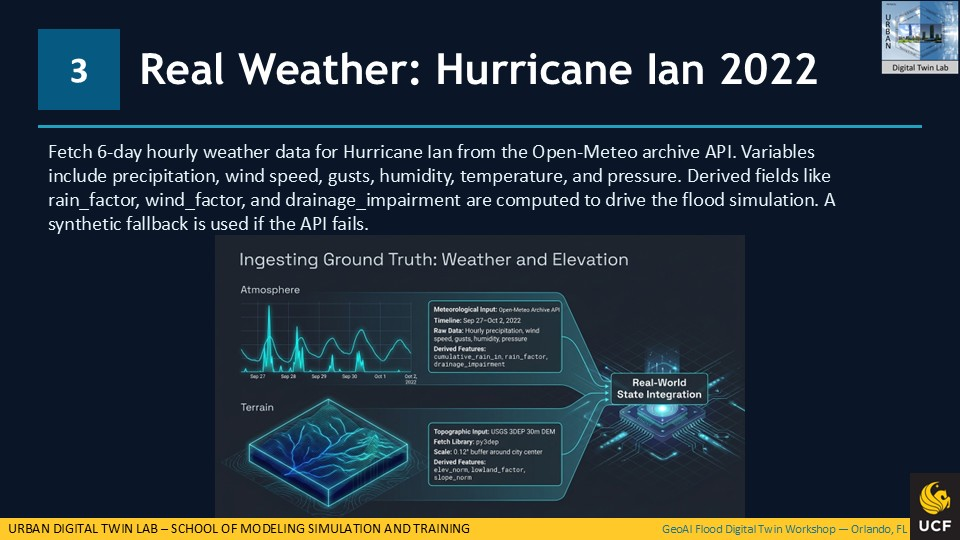

In [ ]:
def load_open_meteo_ian_weather(lat=LAT, lon=LON):
    import openmeteo_requests, requests_cache
    from retry_requests import retry
    cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": "2022-09-27", "end_date": "2022-10-02",
        "hourly": ["temperature_2m", "relative_humidity_2m", "precipitation", "rain", "wind_speed_10m", "wind_gusts_10m", "surface_pressure"],
        "timezone": "America/New_York",
    }
    response = openmeteo.weather_api(url, params=params)[0]
    hourly = response.Hourly()
    data = {"time": pd.date_range(start=pd.to_datetime(hourly.Time(), unit="s", utc=True), end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True), freq=pd.Timedelta(seconds=hourly.Interval()), inclusive="left")}
    data["temperature_c"] = hourly.Variables(0).ValuesAsNumpy()
    data["humidity_pct"] = hourly.Variables(1).ValuesAsNumpy()
    data["precip_mm"] = hourly.Variables(2).ValuesAsNumpy()
    data["rain_mm"] = hourly.Variables(3).ValuesAsNumpy()
    data["wind_speed_kmh"] = hourly.Variables(4).ValuesAsNumpy()
    data["wind_gust_kmh"] = hourly.Variables(5).ValuesAsNumpy()
    data["pressure_hpa"] = hourly.Variables(6).ValuesAsNumpy()
    df = pd.DataFrame(data)
    df["time"] = pd.to_datetime(df["time"]).dt.tz_convert("America/New_York")
    df["rain_in"] = df["precip_mm"] / 25.4
    df["cumulative_rain_in"] = df["rain_in"].cumsum()
    df["wind_mph"] = df["wind_speed_kmh"] * 0.621371
    df["gust_mph"] = df["wind_gust_kmh"] * 0.621371
    df["rain_factor"] = df["cumulative_rain_in"] / (df["cumulative_rain_in"].max() + 1e-9)
    df["wind_factor"] = df["gust_mph"] / (df["gust_mph"].max() + 1e-9)
    df["drainage_impairment"] = (1.0 + 0.3 * df["rain_factor"]).clip(1.0, 1.8)
    return df

def fallback_ian_weather():
    times = pd.date_range("2022-09-27", "2022-10-02 23:00", freq="h", tz="America/New_York")
    t = np.arange(len(times)); peak = 45
    rain_shape = np.exp(-((t - peak) / 14) ** 2)
    hourly_rain = 0.55 * rain_shape + 0.08 * np.exp(-((t - 30) / 10) ** 2)
    wind = 18 + 38 * np.exp(-((t - peak) / 18) ** 2)
    df = pd.DataFrame({"time": times, "temperature_c": 24 + 2*np.sin(t/24*2*np.pi), "humidity_pct": 85 + 10*rain_shape, "precip_mm": hourly_rain*25.4, "rain_mm": hourly_rain*25.4, "wind_speed_kmh": wind/0.621371, "wind_gust_kmh": (wind*1.35)/0.621371, "pressure_hpa": 1008 - 20*rain_shape})
    df["rain_in"] = df["precip_mm"] / 25.4
    df["cumulative_rain_in"] = df["rain_in"].cumsum()
    df["wind_mph"] = df["wind_speed_kmh"] * 0.621371
    df["gust_mph"] = df["wind_gust_kmh"] * 0.621371
    df["rain_factor"] = df["cumulative_rain_in"] / (df["cumulative_rain_in"].max() + 1e-9)
    df["wind_factor"] = df["gust_mph"] / (df["gust_mph"].max() + 1e-9)
    df["drainage_impairment"] = (1.0 + 0.8 * df["rain_factor"]).clip(1.0, 1.8)
    return df

try:
    weather_df = load_open_meteo_ian_weather() if USE_REAL_WEATHER else fallback_ian_weather()
    weather_source = "Open-Meteo Archive"
except Exception as e:
    print("⚠️ Open-Meteo failed. Using fallback Ian-shaped weather.")
    print("Reason:", e)
    weather_df = fallback_ian_weather()
    weather_source = "Fallback synthetic Ian-shaped weather"

print(f"Weather source: {weather_source}")
print(f"Total rainfall: {weather_df['cumulative_rain_in'].iloc[-1]:.2f} inches")
print(f"Peak hourly rain: {weather_df['rain_in'].max():.2f} in/hr")
print(f"Peak gust: {weather_df['gust_mph'].max():.1f} mph")
display(weather_df.head())

Weather source: Open-Meteo Archive
Total rainfall: 10.41 inches
Peak hourly rain: 1.45 in/hr
Peak gust: 59.3 mph


,time,temperature_c,humidity_pct,precip_mm,rain_mm,wind_speed_kmh,wind_gust_kmh,pressure_hpa,rain_in,cumulative_rain_in,wind_mph,gust_mph,rain_factor,wind_factor,drainage_impairment
0,2022-09-27 00:00:00-04:00,22.750000,93.521683,1.4,1.4,2.880000,13.679999,1009.215271,0.055118,0.055118,1.789548,8.500355,0.005297,0.143396,1.001589
1,2022-09-27 01:00:00-04:00,22.799999,94.097206,0.3,0.3,3.075841,5.400000,1009.116333,0.011811,0.066929,1.911239,3.355403,0.006432,0.056604,1.001930
2,2022-09-27 02:00:00-04:00,22.799999,95.252724,0.2,0.2,3.396233,6.480000,1008.717896,0.007874,0.074803,2.110321,4.026484,0.007189,0.067925,1.002157
3,2022-09-27 03:00:00-04:00,22.799999,96.127472,0.1,0.1,2.414953,6.120000,1008.020691,0.003937,0.078740,1.500582,3.802790,0.007567,0.064151,1.002270
4,2022-09-27 04:00:00-04:00,22.750000,97.008163,0.0,0.0,2.305125,4.680000,1007.322998,0.000000,0.078740,1.432338,2.908016,0.007567,0.049057,1.002270


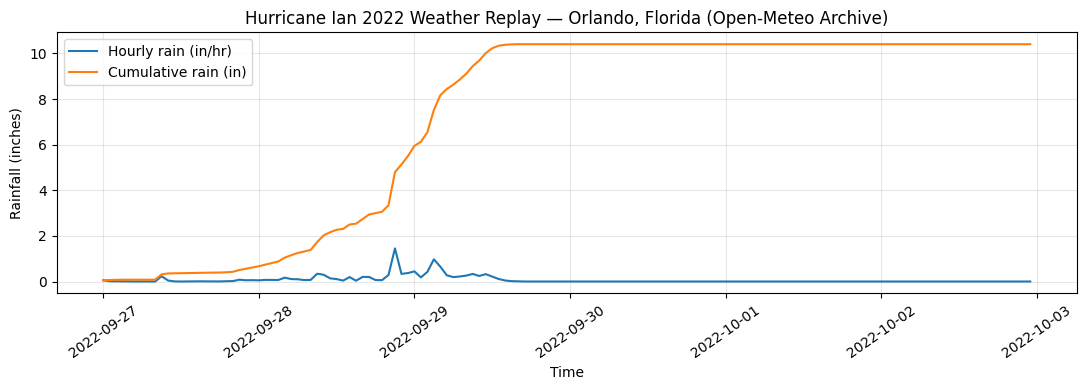

In [ ]:
plt.figure(figsize=(11, 4))
plt.plot(weather_df["time"], weather_df["rain_in"], label="Hourly rain (in/hr)")
plt.plot(weather_df["time"], weather_df["cumulative_rain_in"], label="Cumulative rain (in)")
plt.title(f"Hurricane Ian 2022 Weather Replay — {SELECTED_CITY} ({weather_source})")
plt.xlabel("Time"); plt.ylabel("Rainfall (inches)"); plt.xticks(rotation=35); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

**👀 Look at the chart:** two visible peaks — first as Ian's outer bands hit around hour 30, then the main rainfall arrival (~hour 60-80). This is the storm's *shape*. Every flood prediction below is driven by this curve. If the curve is real, the floods are physically plausible.

## 4 · Real Elevation: USGS 3DEP DEM

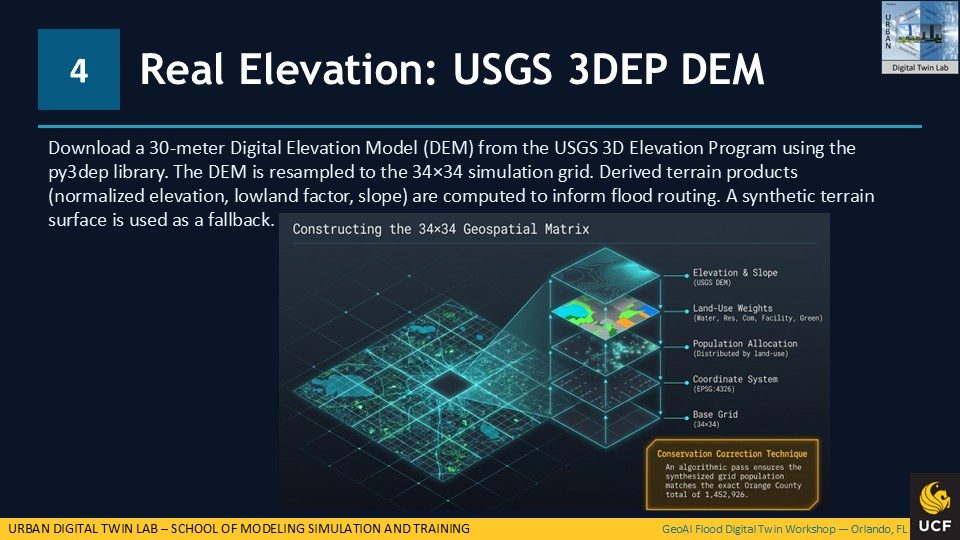

Pulls a 30 m DEM around the study area using `py3dep`. If that fails, the notebook falls back to a synthetic terrain surface (This is made only to continue the workshop).

DEM source: USGS 3DEP DEM via py3dep
Elevation min/mean/max: 7.46 / 27.89 / 57.02 m


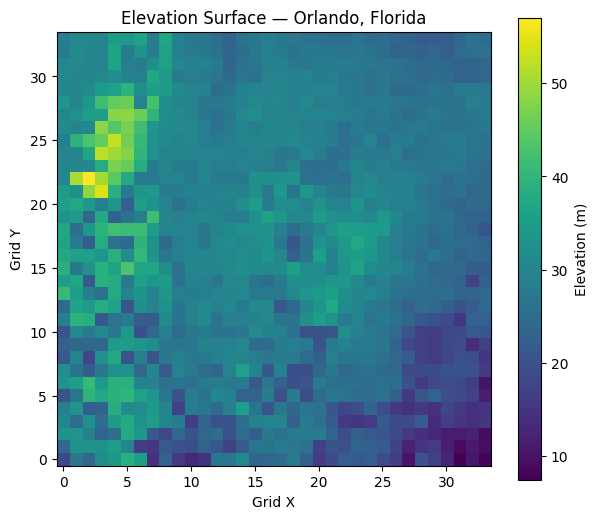

In [ ]:
def load_usgs_dem(lat=LAT, lon=LON, grid=GRID, buffer_deg=0.12):
    import py3dep
    from scipy.ndimage import zoom as scipy_zoom
    bbox = (lon - buffer_deg, lat - buffer_deg, lon + buffer_deg, lat + buffer_deg)
    dem = py3dep.get_dem(bbox, resolution=30)
    dem_array = dem.values.astype(float)
    dem_array = np.where(np.isfinite(dem_array), dem_array, np.nan)
    dem_array = np.nan_to_num(dem_array, nan=np.nanmedian(dem_array))
    return scipy_zoom(dem_array, (grid/dem_array.shape[0], grid/dem_array.shape[1]), order=1)

def fallback_dem(grid=GRID):
    y, x = np.mgrid[0:grid, 0:grid]
    base = 28 + 4*(x/grid) + 2*np.sin(y/5)
    channel = 5*np.exp(-((x - grid*0.35)/4)**2)
    basin = 3*np.exp(-(((x-grid*0.65)**2 + (y-grid*0.45)**2)/(2*7**2)))
    return base - channel - basin

try:
    real_elevation = load_usgs_dem() if USE_REAL_DEM else fallback_dem()
    dem_source = "USGS 3DEP DEM via py3dep"
except Exception as e:
    print("⚠️ USGS DEM failed. Using fallback synthetic terrain.")
    print("Reason:", e)
    real_elevation = fallback_dem()
    dem_source = "Fallback synthetic terrain"

ELEVATION = real_elevation.astype(float)
elev_norm = (ELEVATION - ELEVATION.min()) / (ELEVATION.max() - ELEVATION.min() + 1e-9)
lowland_factor = 1.0 - elev_norm
slope_y, slope_x = np.gradient(ELEVATION)
slope = np.sqrt(slope_x**2 + slope_y**2)
slope_norm = slope / (slope.max() + 1e-9)
print(f"DEM source: {dem_source}")
print(f"Elevation min/mean/max: {ELEVATION.min():.2f} / {ELEVATION.mean():.2f} / {ELEVATION.max():.2f} m")
plt.figure(figsize=(7, 6)); plt.imshow(ELEVATION, origin="lower"); plt.colorbar(label="Elevation (m)"); plt.title(f"Elevation Surface — {SELECTED_CITY}"); plt.xlabel("Grid X"); plt.ylabel("Grid Y"); plt.show()

## 5 · Build Geospatial Grid and Features
Each grid cell becomes one spatial unit for GeoAI prediction and risk mapping.

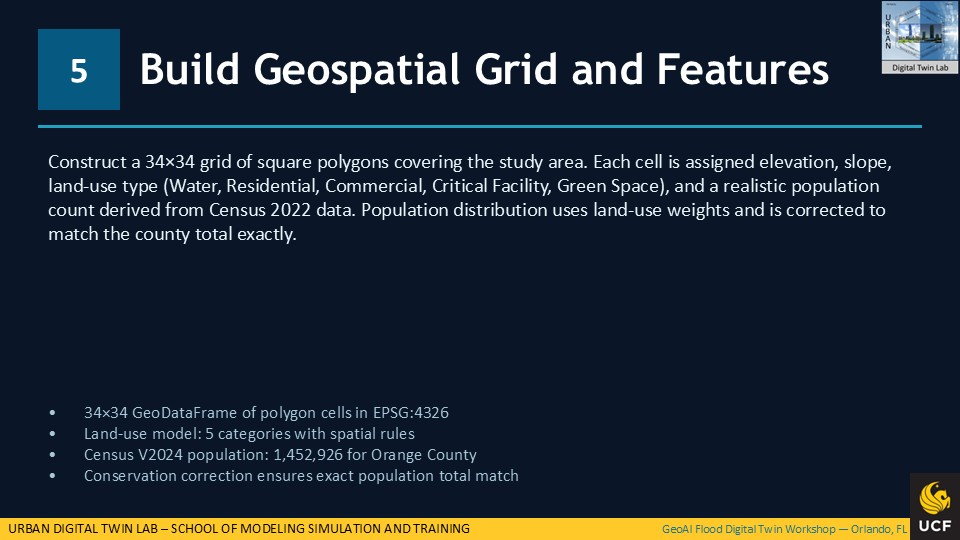

In [ ]:
def make_grid(lat0=LAT, lon0=LON, grid=GRID, cell_deg=CELL_DEG):
    records = []
    for i in range(grid):
        for j in range(grid):
            lat = lat0 + (i - grid / 2) * cell_deg
            lon = lon0 + (j - grid / 2) * cell_deg
            poly = Polygon([
                (lon - cell_deg / 2, lat - cell_deg / 2),
                (lon + cell_deg / 2, lat - cell_deg / 2),
                (lon + cell_deg / 2, lat + cell_deg / 2),
                (lon - cell_deg / 2, lat + cell_deg / 2),
            ])
            records.append({"row": i, "col": j, "lat": lat, "lon": lon, "geometry": poly})
    return gpd.GeoDataFrame(records, crs="EPSG:4326")

# 1. Create spatial grid
grid_gdf = make_grid()
grid_gdf["elevation_m"] = ELEVATION.ravel()
grid_gdf["elev_norm"] = elev_norm.ravel()
grid_gdf["lowland_factor"] = lowland_factor.ravel()
grid_gdf["slope_norm"] = slope_norm.ravel()

r = grid_gdf["row"].values.astype(float)
c = grid_gdf["col"].values.astype(float)
center_dist = np.clip(np.sqrt((r - GRID/2)**2 + (c - GRID/2)**2) / (GRID/2), 0, 1)
grid_gdf["center_dist"] = center_dist

# 2. Land-use model
landuse = np.full(len(grid_gdf), 1)
landuse[center_dist < 0.25] = 2
landuse[(c < GRID * 0.30) & (grid_gdf["lowland_factor"].values > 0.60)] = 0
landuse[(r > GRID * 0.70) & (c > GRID * 0.60)] = 4
landuse[(np.abs(r - GRID * 0.52) < 2) & (np.abs(c - GRID * 0.55) < 2)] = 3
grid_gdf["landuse"] = landuse

LU_LABELS = {0: "Water/Open", 1: "Residential", 2: "Commercial", 3: "Critical Facility", 4: "Green Space"}
grid_gdf["landuse_label"] = grid_gdf["landuse"].map(LU_LABELS)

# 3. Use Census-derived population (V2024 QuickFacts)
COUNTY_POP_2022 = {
    "Orlando, Florida": 1452926,    # Orange County, FL #https://www.census.gov/quickfacts/fact/table/universitycdporangecountyflorida,orangecountyflorida/PST045224#PST045224

}

try:
    total_pop = COUNTY_POP_2022[SELECTED_CITY]
    print(f"✅ Census population (V2024 QuickFacts) loaded: {SELECTED_CITY} = {total_pop:,}")
except KeyError:
    print(f"⚠️ No Census data for {SELECTED_CITY}. Using fallback.")
    total_pop = 1430000

# 4. Distribute population across the grid using land-use and exposure weights
np.random.seed(42)
urban_core = np.clip(1.0 - grid_gdf["center_dist"].values, 0, 1)
weights = urban_core.copy()
weights *= np.where(grid_gdf["landuse"].values == 2, 2.2, 1.0) # Commercial
weights *= np.where(grid_gdf["landuse"].values == 1, 1.3, 1.0) # Residential
weights *= np.where(grid_gdf["landuse"].values == 3, 1.8, 1.0) # Facility
weights *= np.where(grid_gdf["landuse"].values == 4, 0.12, 1.0) # Green
weights *= np.where(grid_gdf["landuse"].values == 0, 0.01, 1.0) # Water
weights *= np.random.uniform(0.75, 1.25, len(weights))
weights = (weights / weights.sum()) * (0.6 + 0.4 * grid_gdf["lowland_factor"].values)
pop_values = np.round((weights / weights.sum()) * total_pop).astype(int)

# 5. Conservation Correction (Ensure exact match with target total)
rounding_error = int(total_pop - pop_values.sum())
if rounding_error != 0:
    developed_mask = grid_gdf["landuse"].isin([1, 2, 3]).values
    ranked_indices = np.where(developed_mask)[0][np.argsort(weights[developed_mask])[::-1]]
    step = 1 if rounding_error > 0 else -1
    for i in range(abs(rounding_error)):
        pop_values[ranked_indices[i % len(ranked_indices)]] += step

grid_gdf["population"] = pop_values

# 6. Validation
print(f"Grid cells: {len(grid_gdf)} | Difference: {int(grid_gdf['population'].sum() - total_pop)}")
display(grid_gdf.groupby("landuse_label")["population"].describe()[["count", "mean", "max"]].round(1))
display(grid_gdf[["row", "col", "elevation_m", "landuse_label", "population"]].head())

✅ Census population (V2024 QuickFacts) loaded: Orlando, Florida = 1,452,926
Grid cells: 1156 | Difference: 0


,count,mean,max
landuse_label,,,
Commercial,45.0,6261.5,8811.0
Critical Facility,16.0,5383.3,7300.0
Green Space,130.0,54.2,235.0
Residential,890.0,1210.8,4400.0
Water/Open,75.0,5.3,23.0


,row,col,elevation_m,landuse_label,population
0,0,0,18.217932,Water/Open,0
1,0,1,27.029318,Water/Open,0
2,0,2,24.292193,Water/Open,0
3,0,3,31.317842,Residential,0
4,0,4,33.799582,Residential,0


<Figure size 700x600 with 0 Axes>

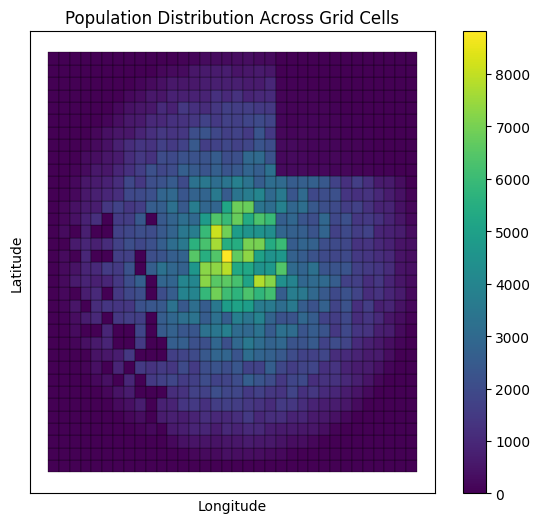

In [ ]:
plt.figure(figsize=(7, 6))
grid_gdf.plot(column='population', legend=True, cmap='viridis', figsize=(7, 6), edgecolor='black', linewidth=0.2)
plt.title('Population Distribution Across Grid Cells')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xticks([]); plt.yticks([]) # Hide axis ticks
plt.show()

## 6 · Terrain-Aware Flood Simulator
Simple simulation uses rainfall, wind, drainage, low elevation, and slope.

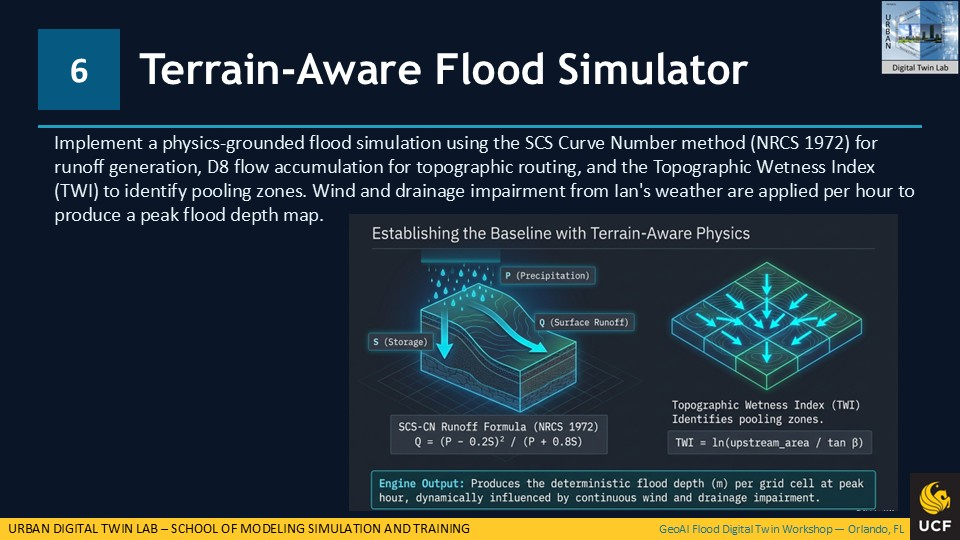

Peak hour: 67/143 | depth: 0.89 m | mean: 0.288 m


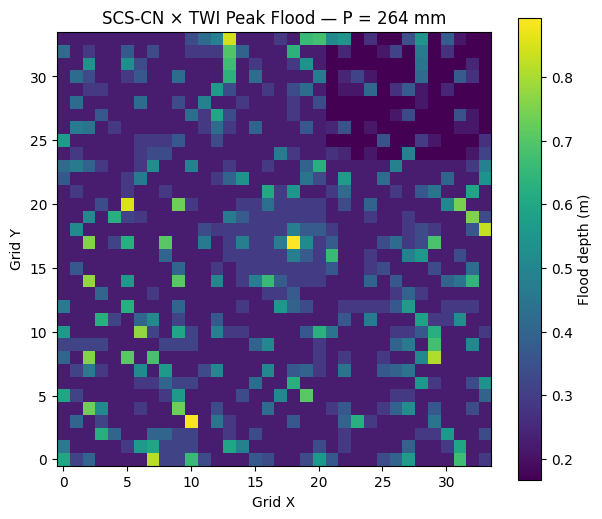

In [ ]:
# ── One-time precomputes ────────────────────────────────────────────────────
if "cumulative_rain_mm" not in weather_df.columns:
    weather_df["cumulative_rain_mm"] = weather_df["precip_mm"].cumsum()

# Curve Number per cell (NRCS TR-55, Type B soil)
CN_BY_LANDUSE = {0: 98, 1: 75, 2: 92, 3: 92, 4: 61}
grid_gdf["CN"] = grid_gdf["landuse"].map(CN_BY_LANDUSE).astype(float)
CN_grid = grid_gdf["CN"].values.reshape(GRID, GRID)

# Topographic Wetness Index: TWI = ln(a / tan β)   (Beven & Kirkby 1979)
def _d8_accumulation(elev):
    H, W = elev.shape
    di = [-1,-1,-1, 0, 0, 1, 1, 1]
    dj = [-1, 0, 1,-1, 1,-1, 0, 1]
    flow_to = np.full((H, W, 2), -1, dtype=int)
    for i in range(H):
        for j in range(W):
            best = elev[i, j]
            for k in range(8):
                ni, nj = i + di[k], j + dj[k]
                if 0 <= ni < H and 0 <= nj < W and elev[ni, nj] < best:
                    best = elev[ni, nj]
                    flow_to[i, j] = [ni, nj]
    acc = np.ones((H, W))
    for idx in np.argsort(-elev, axis=None):
        i, j = np.unravel_index(idx, (H, W))
        ti, tj = flow_to[i, j]
        if ti >= 0:
            acc[ti, tj] += acc[i, j]
    return acc

upstream_area = _d8_accumulation(ELEVATION)
twi = np.log((upstream_area + 1.0) / (slope + 1e-6))
twi_norm = (twi - twi.min()) / (twi.max() - twi.min() + 1e-9)
grid_gdf["twi_norm"] = twi_norm.ravel()

# ── Physics-grounded flood model ────────────────────────────────────────────
# 1) SCS-CN runoff (NRCS 1972):  Q = (P − 0.2S)² / (P + 0.8S),   S = 25400/CN − 254 mm
# 2) Spatial pooling by TWI       (where water goes by topography)
# 3) Drainage = multiplicative sink on runoff (mass balance, not additive)
def simulate_dynamic_flood(P_mm, wind_factor, drainage_factor):
    # SCS-CN runoff generation (NRCS 1972)
    S  = 25400.0 / CN_grid - 254.0
    Ia = 0.2 * S
    Q  = np.where(P_mm > Ia, (P_mm - Ia) ** 2 / (P_mm + 0.8 * S), 0.0)
    # D8 accumulation drives spatial concentration (sub-linear, Manning-style)
    accum_weight = (upstream_area ** 0.35) / (upstream_area ** 0.35).mean()
    # Wind-driven drainage impairment (debris, inlet blockage)
    wind_impairment = 1.0 + 0.25 * wind_factor
    depth_mm = Q * accum_weight * wind_impairment * drainage_factor
    return np.clip(depth_mm / 1000.0, 0, None)

# ── Apply to Hurricane Ian event ────────────────────────────────────────────
depth_by_hour = []
for _, r in weather_df.iterrows():
    f = simulate_dynamic_flood(
        float(r["cumulative_rain_mm"]),
        float(r["wind_factor"]),
        float(r["drainage_impairment"])
    )
    depth_by_hour.append(f.max())
peak_idx       = int(np.argmax(depth_by_hour))
peak_row       = weather_df.iloc[peak_idx]
P_event_mm     = float(peak_row["cumulative_rain_mm"])
baseline_flood = simulate_dynamic_flood(
    P_event_mm, float(peak_row["wind_factor"]), float(peak_row["drainage_impairment"])
)
print(f"Peak hour: {peak_idx}/{len(weather_df)-1} | depth: {baseline_flood.max():.2f} m | mean: {baseline_flood.mean():.3f} m")
grid_gdf["baseline_flood_m"] = baseline_flood.ravel()

CLS_LABELS = {0:"None/Minimal", 1:"Minor", 2:"Moderate", 3:"Major", 4:"Extreme"}
FLOOD_THRESHOLDS_M = [0.02, 0.10, 0.25, 0.50]  # Update thresholds
def classify_flood(x):
    x = np.asarray(x, dtype=float)
    return np.select(
        [x < FLOOD_THRESHOLDS_M[0],
         x < FLOOD_THRESHOLDS_M[1],
         x < FLOOD_THRESHOLDS_M[2],
         x < FLOOD_THRESHOLDS_M[3]],
        [0, 1, 2, 3],
        default=4,
    )

grid_gdf["flood_class"] = classify_flood(grid_gdf["baseline_flood_m"].values)
grid_gdf["flood_label"] = grid_gdf["flood_class"].map(CLS_LABELS)

plt.figure(figsize=(7, 6))
plt.imshow(baseline_flood, origin="lower")
plt.colorbar(label="Flood depth (m)")
plt.title(f"SCS-CN × TWI Peak Flood — P = {P_event_mm:.0f} mm")
plt.xlabel("Grid X"); plt.ylabel("Grid Y")
plt.show()

## 7 · GeoAI Model: Random Forest Flood Classification
Train a surrogate model over the Ian weather timeline and scaled variants.

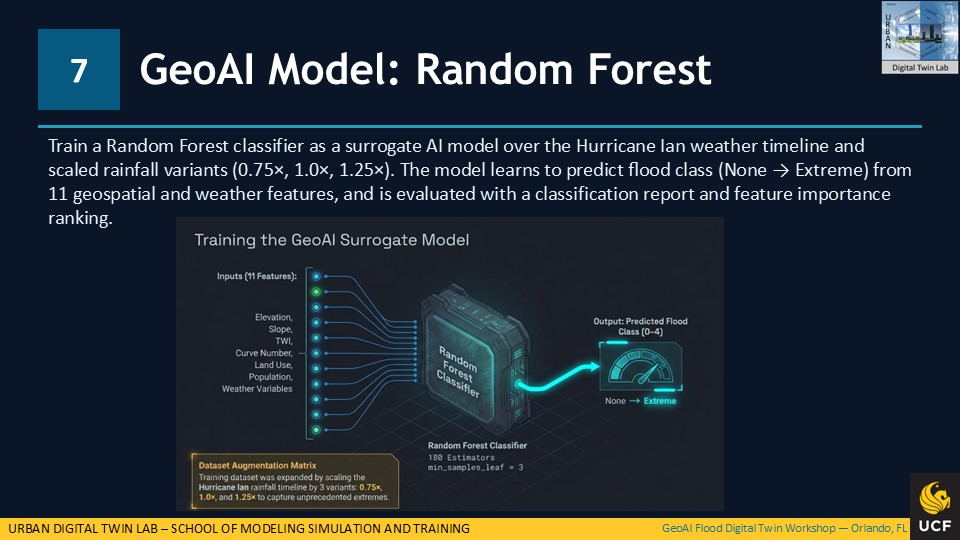

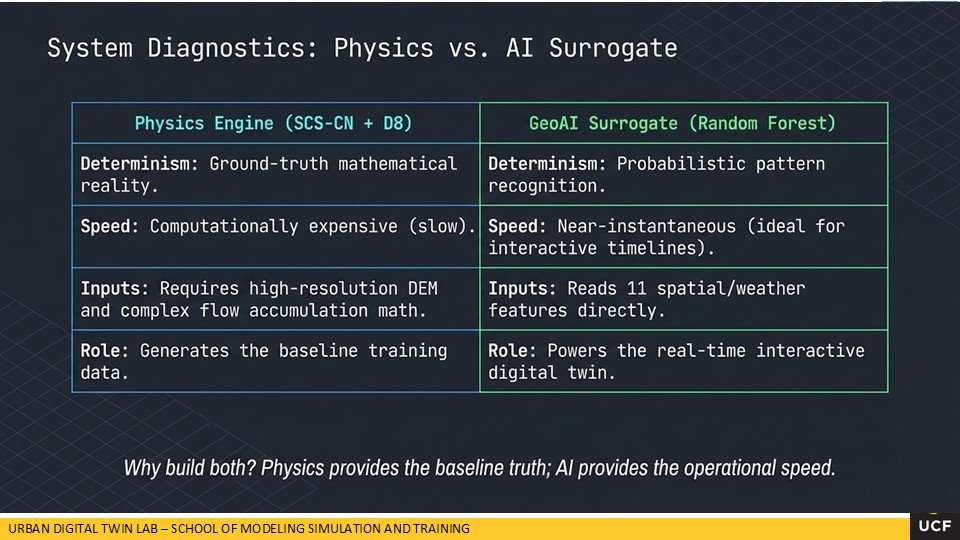

In [ ]:
train_parts = []
for scale in [0.75, 1.00, 1.25]:
    for _, row in weather_df.iterrows():
        P_mm     = float(row["cumulative_rain_mm"]) * scale
        wind     = min(1.0, float(row["wind_factor"]) * scale)
        drainage = float(row["drainage_impairment"])
        flood    = simulate_dynamic_flood(P_mm, wind, drainage).ravel()
        train_parts.append(pd.DataFrame({
            "elevation_m":    grid_gdf["elevation_m"].values,
            "elev_norm":      grid_gdf["elev_norm"].values,
            "lowland_factor": grid_gdf["lowland_factor"].values,
            "slope_norm":     grid_gdf["slope_norm"].values,
            "twi_norm":       grid_gdf["twi_norm"].values,
            "CN":             grid_gdf["CN"].values,
            "landuse":        grid_gdf["landuse"].values,
            "population":     grid_gdf["population"].values,
            "rain_mm":        P_mm,
            "wind_factor":    wind,
            "drainage_impairment": drainage,
            "flood_class":    classify_flood(flood),
        }))

train_df = pd.concat(train_parts, ignore_index=True)
features = ["elevation_m", "elev_norm", "lowland_factor", "slope_norm",
            "twi_norm", "CN", "landuse", "population",
            "rain_mm", "wind_factor", "drainage_impairment"]

X, y = train_df[features], train_df["flood_class"]
stratify_arg = y if y.value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=stratify_arg
)

rf = RandomForestClassifier(n_estimators=180, random_state=42,
                            min_samples_leaf=3, n_jobs=-1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print(f"GeoAI model accuracy: {accuracy_score(y_test, pred):.3f}")
print(classification_report(
    y_test, pred,
    labels=[0, 1, 2, 3, 4],
    target_names=[CLS_LABELS[i] for i in sorted(CLS_LABELS)],
    zero_division=0,
))

importance = (pd.DataFrame({"feature": features,
                            "importance": rf.feature_importances_})
                .sort_values("importance", ascending=False))
display(importance)

GeoAI model accuracy: 0.996
              precision    recall  f1-score   support

None/Minimal       1.00      1.00      1.00     33599
       Minor       0.99      0.98      0.99     10150
    Moderate       1.00      1.00      1.00     43473
       Major       1.00      1.00      1.00     32346
     Extreme       0.99      0.99      0.99      5280

    accuracy                           1.00    124848
   macro avg       0.99      0.99      0.99    124848
weighted avg       1.00      1.00      1.00    124848



,feature,importance
8,rain_mm,0.466970
10,drainage_impairment,0.195078
4,twi_norm,0.081175
9,wind_factor,0.049245
3,slope_norm,0.049209
5,CN,0.034264
7,population,0.025546
6,landuse,0.025453
1,elev_norm,0.024651
0,elevation_m,0.024413


## 8 · Risk Scoring and Hotspot Detection
Risk combines flood severity, population exposure, terrain, and land-use sensitivity.

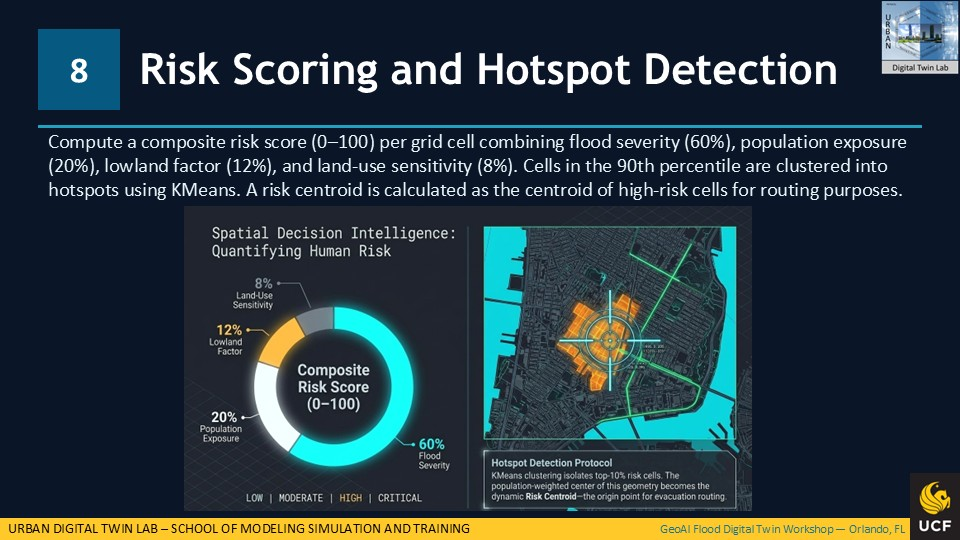

In [ ]:
peak_features = grid_gdf.copy()
peak_features["rain_mm"] = float(peak_row["cumulative_rain_mm"])
peak_features["wind_factor"] = float(peak_row["wind_factor"])
peak_features["drainage_impairment"] = float(peak_row["drainage_impairment"])

flood_vals = grid_gdf["baseline_flood_m"].values
print("Flood depth stats:")
print("Min:", flood_vals.min())
print("Max:", flood_vals.max())
print("Mean:", flood_vals.mean())

# Use the trained GeoAI model to predict flood classes
grid_gdf["geoai_flood_class"] = rf.predict(peak_features[features])
grid_gdf["geoai_flood_label"] = grid_gdf["geoai_flood_class"].map(CLS_LABELS)

pop_norm = grid_gdf["population"] / (grid_gdf["population"].max() + 1e-9)
landuse_weight = grid_gdf["landuse"].map({0:0.6, 1:0.8, 2:1.0, 3:1.2, 4:0.4}).values
flood_norm = grid_gdf["baseline_flood_m"] / (grid_gdf["baseline_flood_m"].max() + 1e-9)
grid_gdf["risk_score"] = 100 * (0.60*flood_norm + 0.20*pop_norm + 0.12*grid_gdf["lowland_factor"] + 0.08*landuse_weight/1.2)

def risk_tier(score):
    if score >= 50: return "CRITICAL"
    if score >= 35: return "HIGH"
    if score >= 20: return "MODERATE"
    return "LOW"
grid_gdf["risk_tier"] = grid_gdf["risk_score"].apply(risk_tier)
high_risk = grid_gdf[grid_gdf["risk_score"] >= grid_gdf["risk_score"].quantile(0.90)].copy()
if len(high_risk) >= 3:
    km = KMeans(n_clusters=min(3, len(high_risk)), random_state=42, n_init=10)
    high_risk["hotspot_cluster"] = km.fit_predict(high_risk[["lat", "lon"]])
else:
    high_risk["hotspot_cluster"] = 0
risk_centroid_lat = float(high_risk["lat"].mean()); risk_centroid_lon = float(high_risk["lon"].mean())
summary = grid_gdf.groupby("risk_tier").size().reindex(["LOW", "MODERATE", "HIGH", "CRITICAL"], fill_value=0)
display(summary.to_frame("cell_count"))
print(f"Risk centroid: {risk_centroid_lat:.4f}, {risk_centroid_lon:.4f}")

Flood depth stats:
Min: 0.1671332361535817
Max: 0.8931309209444626
Mean: 0.2880300249139697


,cell_count
risk_tier,
LOW,0
MODERATE,802
HIGH,252
CRITICAL,102


Risk centroid: 28.5213, -81.3815


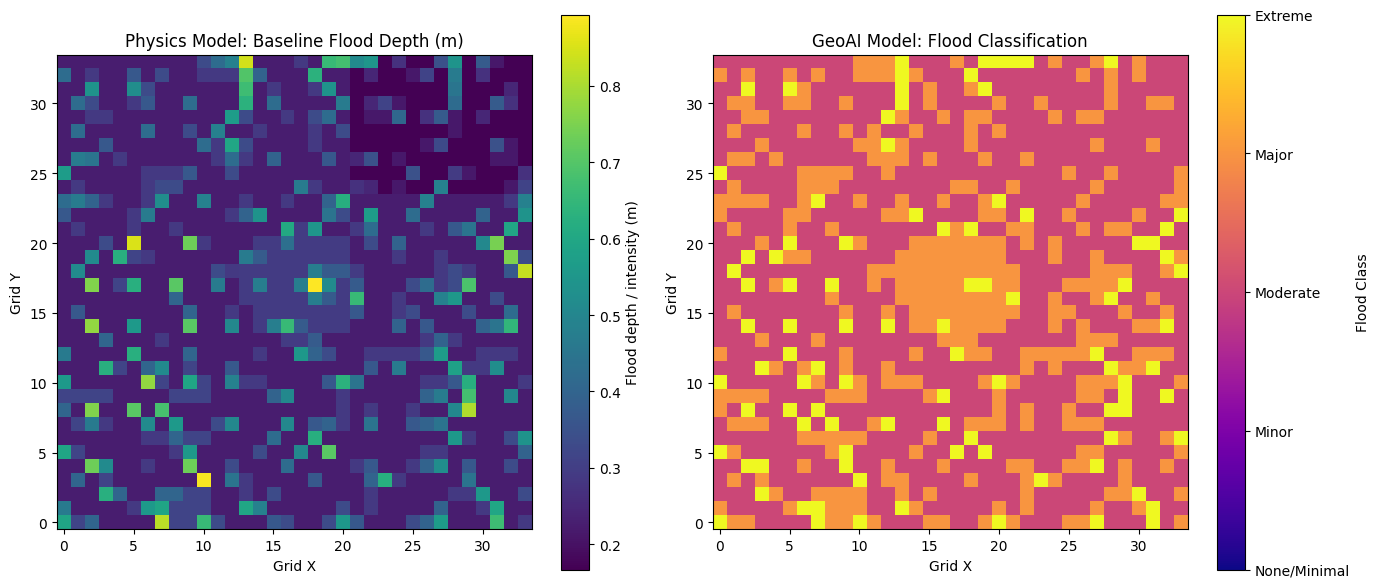

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Physics Model Flood
im1 = axes[0].imshow(grid_gdf['baseline_flood_m'].values.reshape(GRID, GRID), origin='lower', cmap='viridis')
axes[0].set_title('Physics Model: Baseline Flood Depth (m)')
axes[0].set_xlabel('Grid X'); axes[0].set_ylabel('Grid Y')
fig.colorbar(im1, ax=axes[0], label='Flood depth / intensity (m)')

# Plot GeoAI Model Flood Classification
flood_class_grid = grid_gdf["geoai_flood_class"].values.reshape(GRID, GRID)

im2 = axes[1].imshow(
    flood_class_grid,
    origin="lower",
    cmap="plasma",
    vmin=0,
    vmax=4
)
axes[1].set_title('GeoAI Model: Flood Classification')
axes[1].set_xlabel('Grid X'); axes[1].set_ylabel('Grid Y')
cbar = fig.colorbar(im2, ax=axes[1], ticks=[0, 1, 2, 3, 4], label='Flood Class')
cbar.set_ticklabels([CLS_LABELS[i] for i in range(5)])

plt.tight_layout()
plt.show()

In [ ]:
# This cell defines a set of helper functions critical for the GeoAI Flood Digital Twin.
# It includes logic for calculating flood depth at specific locations, building evacuation routes,
# making dynamic decisions about shelter selection based on flood conditions, and constructing
# an interactive Folium map to visualize flood surfaces, risk, and evacuation plans.
# These functions collectively enable the real-time replay and decision-making capabilities of the digital twin.

from branca.element import Figure

# ── Evacuation exit zones outside the flood grid ─────────────────────────────
evac_zones = pd.DataFrame({
    "name": ["North Evacuation Exit", "East Evacuation Exit", "South Evacuation Exit", "West Evacuation Exit"],
    "lat":  [LAT + 0.18, LAT,        LAT - 0.18, LAT],
    "lon":  [LON,        LON + 0.18, LON,        LON - 0.18],
    "capacity": [999999, 999999, 999999, 999999],
    "is_evac_zone": [True, True, True, True]
})


def get_flood_at_location(flood_surface, lat, lon):
    i = int(round((lat - LAT) / CELL_DEG + GRID / 2))
    j = int(round((lon - LON) / CELL_DEG + GRID / 2))

    if 0 <= i < GRID and 0 <= j < GRID:
        return float(flood_surface[i, j])
    return 0.0   # outside grid treated as outside modeled flood zone


def build_exit_routes():
    exit_records = []

    for _, z in evac_zones.iterrows():
        miles = haversine_miles(risk_centroid_lat, risk_centroid_lon, z["lat"], z["lon"])

        exit_records.append({
            "name": z["name"],
            "lat": z["lat"],
            "lon": z["lon"],
            "capacity": z["capacity"],
            "route": None,
            "route_miles": miles,
            "travel_time_min": miles / 35 * 60,
            "geoai_shelter_score": 0,
            "shelter_flood_m": 0.0,
            "shelter_class": 0,
            "is_safe": True,
            "is_evac_zone": True
        })

    return pd.DataFrame(exit_records)


def choose_dynamic_shelter_or_exit(flood_surface, safe_class_max=1):
    temp = shelters.copy()
    temp["is_evac_zone"] = False

    temp["shelter_flood_m"] = temp.apply(
        lambda s: get_flood_at_location(flood_surface, s["lat"], s["lon"]),
        axis=1
    )

    temp["shelter_class"] = classify_flood(temp["shelter_flood_m"].values)

    # Apply shelter resilience factor
    safe_threshold = FLOOD_THRESHOLDS_M[safe_class_max] * (1 + SHELTER_RESILIENCE)
    temp["is_safe"] = temp["shelter_flood_m"] <= safe_threshold
    temp["adjusted_class"] = temp["shelter_class"]

    safe_temp = temp[temp["is_safe"]].copy()

    if len(safe_temp) > 0:
        selected = safe_temp.sort_values("geoai_shelter_score", ascending=False).iloc[0]
        mode = "Safe shelter selected"
        decision_type = "shelter"
        all_options = temp

    else:
        exit_df = build_exit_routes()

        # choose closest evacuation direction outside modeled flood grid
        selected = exit_df.sort_values("route_miles", ascending=True).iloc[0]

        all_options = pd.concat([temp, exit_df], ignore_index=True)

        mode = "No safe shelters available; evacuation exit selected"
        decision_type = "evacuation_exit"

    return selected, all_options, mode, decision_type


# ── Helper: build a Folium map for any flood surface ─────────────────────────
def build_replay_map(flood_surface, row, dynamic_class, dynamic_risk, dyn_centroid=None, dyn_route=None):
    selected_target, shelter_status, shelter_mode, decision_type = choose_dynamic_shelter_or_exit(
        flood_surface
    )

    m2 = folium.Map(location=[LAT, LON], zoom_start=12, tiles=None)

    folium.TileLayer("OpenStreetMap", name="OpenStreetMap").add_to(m2)

    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri World Imagery",
        name="Satellite Imagery"
    ).add_to(m2)

    fl = FeatureGroup(name="Dynamic Flood", show=True)
    rk = FeatureGroup(name="Dynamic Risk + Decision", show=True)

    flat_flood = flood_surface.ravel()

    for idx2, cell in grid_gdf.iterrows():
        cls = int(dynamic_class[idx2])

        if cls == 0:
            continue

        coords = [(la, lo) for lo, la in list(cell.geometry.exterior.coords)]

        popup = (
            f"<b>Cell ({int(cell.row)}, {int(cell.col)})</b><br>"
            f"Flood class : <b>{CLS_LABELS[cls]}</b><br>"
            f"Depth index : {flat_flood[idx2]:.2f} m<br>"
            f"Elevation   : {cell.elevation_m:.1f} m<br>"
            f"Land use    : {cell.landuse_label}<br>"
            f"Population  : ~{int(cell.population):,}<br>"
            f"Risk score  : <b>{dynamic_risk[idx2]:.1f}/100</b>"
        )

        folium.Polygon(
            coords,
            color=CLS_COLORS[cls],
            fill=True,
            fill_color=CLS_COLORS[cls],
            fill_opacity=0.55,
            weight=0.4,
            popup=folium.Popup(popup, max_width=290),
            tooltip=f"{CLS_LABELS[cls]} | depth {flat_flood[idx2]:.2f} m"
        ).add_to(fl)

    # Dynamic risk markers
    high_mask = dynamic_risk >= 35

    for idx2, cell in grid_gdf[high_mask].iterrows():
        tier = "CRITICAL" if dynamic_risk[idx2] >= 50 else "HIGH"

        folium.CircleMarker(
            location=[cell.lat, cell.lon],
            radius=5 if tier == "CRITICAL" else 3,
            color="black",
            weight=0.5,
            fill=True,
            fill_color=RISK_COLORS.get(tier, "red"),
            fill_opacity=0.88,
            tooltip=f"{tier} | score {dynamic_risk[idx2]:.0f}"
        ).add_to(rk)

    # Shelter + evacuation markers
    for _, s in shelter_status.iterrows():
        is_selected = s["name"] == selected_target["name"]
        is_evac = bool(s.get("is_evac_zone", False))

        if is_evac and is_selected:
            marker_color = "orange"
            icon_name = "road"
        elif is_evac:
            marker_color = "cadetblue"
            icon_name = "road"
        elif is_selected and s["is_safe"]:
            marker_color = "green"
            icon_name = "home"
        elif is_selected and not s["is_safe"]:
            marker_color = "red"
            icon_name = "home"
        elif s["is_safe"]:
            marker_color = "blue"
            icon_name = "home"
        else:
            marker_color = "gray"
            icon_name = "home"

        status_text = "EVACUATION EXIT" if is_evac else ("SAFE" if s["is_safe"] else "UNSAFE / FLOODED")

        popup = f"""
        <b>{s["name"]}</b><br>
        Type: {status_text}<br>
        Capacity: {int(s["capacity"]):,}<br>
        Route distance: {s["route_miles"]:.2f} miles<br>
        Travel time: {s["travel_time_min"]:.1f} min<br>
        Flood depth: {s["shelter_flood_m"]:.2f} m<br>
        Flood class: {CLS_LABELS.get(int(s["shelter_class"]), "Unknown")}
        """

        folium.Marker(
            location=[s.lat, s.lon],
            tooltip=f'{s["name"]} — {status_text}',
            popup=folium.Popup(popup, max_width=300),
            icon=folium.Icon(
                color=marker_color,
                icon=icon_name,
                prefix="fa"
            )
        ).add_to(rk)

    # Draw flood-aware evacuation corridor from dynamic risk centroid to selected shelter
    origin_lat = dyn_centroid[0] if dyn_centroid else risk_centroid_lat
    origin_lon = dyn_centroid[1] if dyn_centroid else risk_centroid_lon

    # Mark the centroid origin
    folium.CircleMarker(
        location=[origin_lat, origin_lon],
        radius=7, color="white", weight=2, fill=True,
        fill_color="purple", fill_opacity=0.9,
        tooltip="Dynamic risk centroid (route origin)"
    ).add_to(rk)

    # Draw the route
    route_to_draw = dyn_route if dyn_route is not None else (
        selected_target["route"] if "route" in selected_target.index else None
    )
    route_drawn = add_osm_route_to_map(m2, G, route_to_draw)

    if not route_drawn:
        folium.PolyLine(
            [[origin_lat, origin_lon],
             [selected_target.lat, selected_target.lon]],
            color="#00ff88" if decision_type == "shelter" else "orange",
            weight=5, opacity=0.9,
            tooltip=f"Route to {selected_target['name']}"
        ).add_to(rk)

    # Dynamic summary banner
    n_major = int((dynamic_class >= 3).sum())
    n_crit = int((dynamic_risk >= 50).sum())
    pop_at_risk = int(grid_gdf["population"].values[dynamic_risk >= 35].sum())
    unsafe_shelters = int(
        ((shelter_status["is_evac_zone"] == False) & (shelter_status["is_safe"] == False)).sum()
    )

    no_safe_msg = ""
    if decision_type == "evacuation_exit":
        no_safe_msg = "<br><b style='color:#ffcc00'>⚠️ NO SAFE SHELTERS — ROUTING TO EVACUATION EXIT</b>"

    time_label = (
        row["time"].strftime("%b %d %H:00")
        if hasattr(row["time"], "strftime")
        else str(row["time"])[:13]
    )

    banner = f"""
    <div style="position:fixed;top:14px;left:50px;z-index:1000;
        background:rgba(11,31,51,0.88);color:white;padding:10px 14px;
        border-radius:8px;font-size:12px;font-family:sans-serif;line-height:1.5">
        <b>🌪️ Hurricane Ian — {time_label}</b><br>
        Cum. rain: {row["cumulative_rain_in"]:.2f} in | Gust: {row["gust_mph"]:.1f} mph<br>
        Flood depth max: {flood_surface.max():.2f} m | Major+ cells: {n_major}<br>
        Critical-risk cells: {n_crit}<br>
        Selected target: <b>{selected_target["name"]}</b><br>
        Unsafe shelters: {unsafe_shelters}<br>
        Shelter status: {shelter_mode}
        {no_safe_msg}
    </div>
    """

    m2.get_root().html.add_child(folium.Element(banner))
    root: Figure = m2.get_root()  # type: ignore[assignment]

    legend = """
    <div style="position:fixed;bottom:28px;left:28px;z-index:1000;background:white;
        padding:12px 14px;border-radius:8px;border:1px solid #bbb;font-size:12px;
        box-shadow:2px 2px 6px rgba(0,0,0,0.2)">
        <b>GeoAI Flood Digital Twin</b><br>
        <span style="color:#ffffb2;font-size:16px">■</span> Minor<br>
        <span style="color:#fd8d3c;font-size:16px">■</span> Moderate<br>
        <span style="color:#d7191c;font-size:16px">■</span> Major<br>
        <span style="color:#6d0000;font-size:16px">■</span> Extreme<br>
        <hr style="margin:5px 0">
        <span style="color:green">⬟</span> Selected safe shelter<br>
        <span style="color:blue">⬟</span> Safe shelter<br>
        <span style="color:gray">⬟</span> Unsafe shelter<br>
        <span style="color:#00ff88">━</span> Evacuation corridor (high-risk centroid → shelter)<br>
        <span style="color:purple">●</span> Dynamic risk centroid<br>
        <span style="color:#7f0000">●</span> High / Critical risk
    </div>
    """

    m2.get_root().html.add_child(folium.Element(legend))

    fl.add_to(m2)
    rk.add_to(m2)
    LayerControl(collapsed=False).add_to(m2)

    return m2, selected_target, shelter_status, shelter_mode, decision_type

print(f"✅ Helper functions registered: get_flood_at_location, build_exit_routes, "
      f"choose_dynamic_shelter_or_exit, build_replay_map")
print(f"   Evacuation exits defined: {len(evac_zones)} | Shelter resilience: {SHELTER_RESILIENCE:.0%}")


✅ Helper functions registered: get_flood_at_location, build_exit_routes, choose_dynamic_shelter_or_exit, build_replay_map
   Evacuation exits defined: 4 | Shelter resilience: 50%


## 9 · Shelters and OSM Road Routing
Uses real OpenStreetMap road routing when available. The downloaded graph is cached as GraphML for reuse.

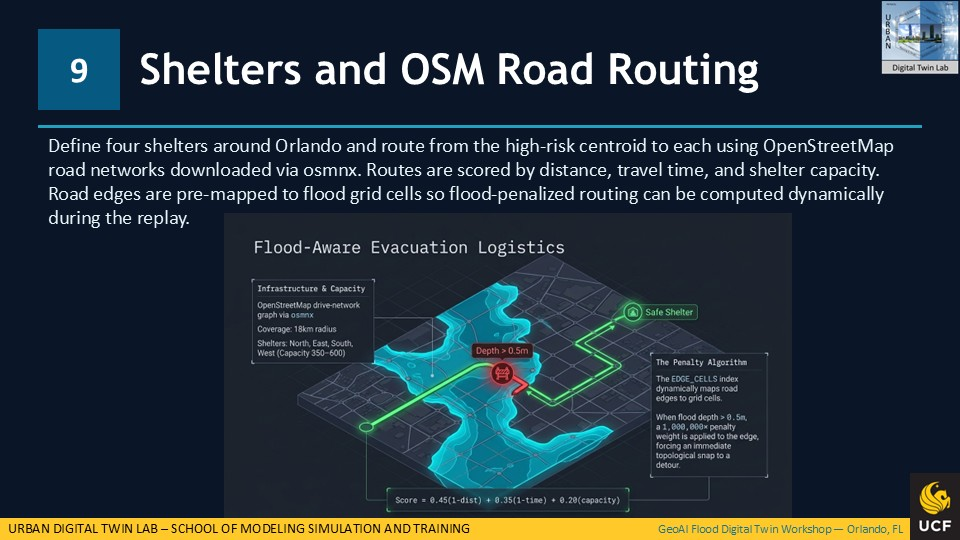

These helper functions are used for dynamic flood simulation, shelter selection, and map rendering.

In [ ]:
import networkx as nx
shelters = pd.DataFrame({"name":["North Shelter","East Shelter","South Shelter","West Shelter"], "lat":[LAT+0.075, LAT+0.020, LAT-0.075, LAT-0.015], "lon":[LON-0.035, LON+0.090, LON+0.020, LON-0.095], "capacity":[450,600,500,350]})
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8; p1, p2 = math.radians(lat1), math.radians(lat2); dphi = math.radians(lat2-lat1); dlambda = math.radians(lon2-lon1)
    a = math.sin(dphi/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlambda/2)**2
    return 2*R*math.asin(math.sqrt(a))
safe_city = SELECTED_CITY.lower().replace(",", "").replace(" ", "_")
osm_graph_path = Path(f"{safe_city}_osm_drive.graphml"); G = None; routing_source = "straight-line fallback"
if USE_OSM_ROUTING:
    try:
        import osmnx as ox
        ox.settings.use_cache = True; ox.settings.log_console = False
        if osm_graph_path.exists():
            G = ox.load_graphml(osm_graph_path); routing_source = "Cached OpenStreetMap graph"
        else:
            print("Downloading OSM road network once")
            G = ox.graph_from_point((LAT, LON), dist=18000, network_type="drive", simplify=True)
            G = ox.add_edge_speeds(G); G = ox.add_edge_travel_times(G); ox.save_graphml(G, osm_graph_path)
            routing_source = "OpenStreetMap road graph"
    except Exception as e:
        print("⚠️ OSM routing failed. Using straight-line fallback."); print("Reason:", e); G = None
route_records = []
if G is not None:
    import osmnx as ox
    origin_node = ox.distance.nearest_nodes(G, risk_centroid_lon, risk_centroid_lat)
    for _, s in shelters.iterrows():
        dest_node = ox.distance.nearest_nodes(G, s["lon"], s["lat"])
        try:
            route = nx.shortest_path(G, origin_node, dest_node, weight="travel_time")
            route_gdf = ox.routing.route_to_gdf(G, route) if hasattr(ox, "routing") else ox.utils_graph.route_to_gdf(G, route)
            length_m = route_gdf["length"].sum(); time_sec = route_gdf["travel_time"].sum() if "travel_time" in route_gdf else np.nan
            route_records.append({**s.to_dict(), "route": route, "route_miles": length_m*MILES_PER_METER, "travel_time_min": time_sec/60 if np.isfinite(time_sec) else np.nan})
        except Exception:
            miles = haversine_miles(risk_centroid_lat, risk_centroid_lon, s["lat"], s["lon"]); route_records.append({**s.to_dict(), "route": None, "route_miles": miles, "travel_time_min": miles/30*60})
else:
    for _, s in shelters.iterrows():
        miles = haversine_miles(risk_centroid_lat, risk_centroid_lon, s["lat"], s["lon"]); route_records.append({**s.to_dict(), "route": None, "route_miles": miles, "travel_time_min": miles/30*60})
shelters = pd.DataFrame(route_records)
shelters["distance_norm"] = shelters["route_miles"] / (shelters["route_miles"].max() + 1e-9)
shelters["time_norm"] = shelters["travel_time_min"] / (shelters["travel_time_min"].max() + 1e-9)
shelters["capacity_norm"] = shelters["capacity"] / (shelters["capacity"].max() + 1e-9)
# Higher score = better shelter (closer, faster, larger capacity)
shelters["geoai_shelter_score"] = (
    0.45 * (1 - shelters["distance_norm"]) +
    0.35 * (1 - shelters["time_norm"]) +
    0.20 * shelters["capacity_norm"]
)
best_shelter = shelters.sort_values("geoai_shelter_score", ascending=False).iloc[0]
print(f"Routing source: {routing_source}")
print(f"Selected shelter: {best_shelter['name']} | {best_shelter['route_miles']:.2f} miles | {best_shelter['travel_time_min']:.1f} min")
display(shelters[["name", "capacity", "route_miles", "travel_time_min", "geoai_shelter_score"]].style
    .format({"route_miles": "{:.2f} miles", "travel_time_min": "{:.1f} min", "geoai_shelter_score": "{:.3f}"})
    .bar(subset=["geoai_shelter_score"], color="#b3d9f7", vmin=0, vmax=1)
    .set_caption("Shelter selection using route distance, travel time, and capacity (higher score = better)"))

# ── Precompute: map each road-graph edge to a flood-grid cell ────────────────
EDGE_CELLS = {}
if G is not None:
    for u, v, k in G.edges(keys=True):
        y_mid = (G.nodes[u]["y"] + G.nodes[v]["y"]) / 2
        x_mid = (G.nodes[u]["x"] + G.nodes[v]["x"]) / 2
        i = int(round((y_mid - LAT) / CELL_DEG + GRID / 2))
        j = int(round((x_mid - LON) / CELL_DEG + GRID / 2))
        EDGE_CELLS[(u, v, k)] = (i, j) if (0 <= i < GRID and 0 <= j < GRID) else None
    print(f"✅ Edge→cell index built: {len(EDGE_CELLS):,} edges mapped")

def compute_dynamic_route(flood_surface, origin_lat, origin_lon, dest_lat, dest_lon):
    """Flood-aware shortest path. <0.1m: no penalty. 0.1-0.5m: 1x-9x slower. >0.5m: effectively impassable."""
    if G is None:
        return None
    try:
        import osmnx as ox
        flood_weights = {}
        for (u, v, k), cell_idx in EDGE_CELLS.items():
            base = G.edges[u, v, k].get("travel_time", 60.0)
            depth = flood_surface[cell_idx] if cell_idx is not None else 0.0
            if depth < 0.1:
                mult = 1.0
            elif depth < 0.5:
                mult = 1.0 + 20.0 * (depth - 0.1)
            else:
                mult = 1e6
            flood_weights[(u, v, k)] = base * mult
        nx.set_edge_attributes(G, flood_weights, "flood_weight")
        o = ox.distance.nearest_nodes(G, origin_lon, origin_lat)
        d = ox.distance.nearest_nodes(G, dest_lon, dest_lat)
        return nx.shortest_path(G, o, d, weight="flood_weight")
    except Exception:
        return None

Routing source: Cached OpenStreetMap graph
Selected shelter: South Shelter | 5.07 miles | 8.2 min


,name,capacity,route_miles,travel_time_min,geoai_shelter_score
0,North Shelter,450,8.49 miles,11.4 min,0.179
1,East Shelter,600,8.91 miles,11.4 min,0.208
2,South Shelter,500,5.07 miles,8.2 min,0.466
3,West Shelter,350,8.68 miles,11.7 min,0.128


✅ Edge→cell index built: 97,637 edges mapped


## 10 · Interactive Satellite Map
Overlays flood severity, risk cells, shelters, hotspot centroid, and the selected evacuation route.

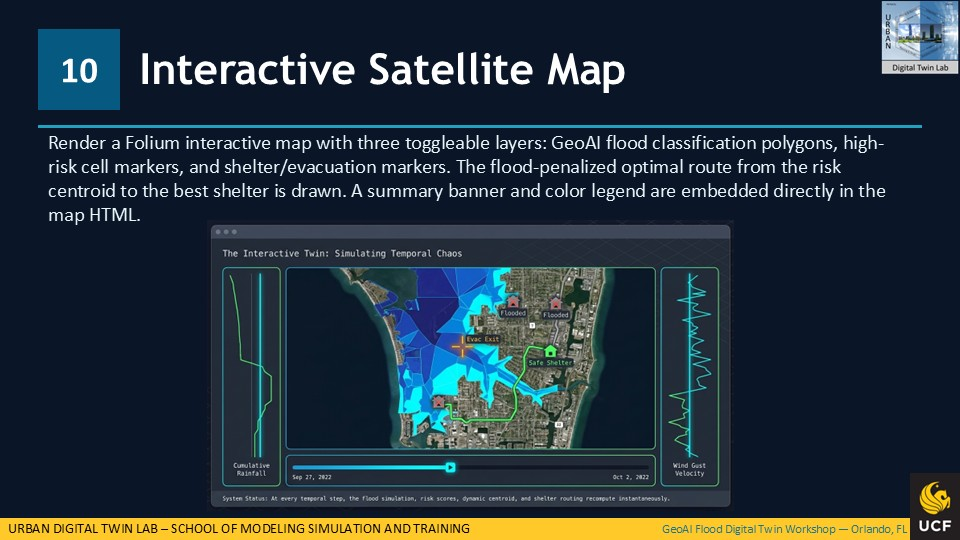

In [ ]:
CLS_COLORS = {0:"#d9f0f7", 1:"#ffffb2", 2:"#fd8d3c", 3:"#d7191c", 4:"#6d0000"}
RISK_COLORS = {"LOW":"#2ca25f", "MODERATE":"#fee08b", "HIGH":"#f46d43", "CRITICAL":"#7f0000"}

def add_osm_route_to_map(m, G, route, color="#00ff88"):
    if G is None or route is None: return False
    try:
        import osmnx as ox
        route_gdf = ox.routing.route_to_gdf(G, route) if hasattr(ox, "routing") else ox.utils_graph.route_to_gdf(G, route)
        coords = []
        for geom in route_gdf.geometry:
            lines = []
            if geom.geom_type == "LineString":
                lines = [geom]
            elif geom.geom_type == "MultiLineString":
                lines = list(geom.geoms)
            else:
                print(f"Warning: Skipping unexpected geometry type in route: {geom.geom_type}")
            for line in lines:
                coords.extend([(lat, lon) for lon, lat in line.coords])
        if coords:
            folium.PolyLine(coords, color=color, weight=5, opacity=0.9, tooltip="OSM route").add_to(m)
            return True
    except Exception as e:
        print("Route drawing fallback:", e)
    return False

m = folium.Map(location=[LAT, LON], zoom_start=12, tiles=None)
folium.TileLayer("OpenStreetMap", name="OpenStreetMap").add_to(m)
folium.TileLayer(tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}", attr="Esri World Imagery", name="Satellite Imagery").add_to(m)
folium.TileLayer("CartoDB positron", name="Light Map").add_to(m)

flood_layer = FeatureGroup(name="GeoAI Flood Classes", show=True)
risk_layer = FeatureGroup(name="High-Risk Cells", show=True)
shelter_layer = FeatureGroup(name="Shelters + Evacuation Route", show=True)

for _, row in grid_gdf.iterrows():
    cls = int(row["geoai_flood_class"])
    if cls == 0: continue
    coords = [(lat, lon) for lon, lat in list(row.geometry.exterior.coords)]
    popup = f"""<b>Cell ({int(row['row'])}, {int(row['col'])})</b><br>GeoAI flood class: <b>{row['geoai_flood_label']}</b><br>Flood depth: {row['baseline_flood_m']:.2f} m<br>Elevation: {row['elevation_m']:.2f} m<br>Land use: {row['landuse_label']}<br>Population: {int(row['population'])}<br>Risk: <b>{row['risk_tier']}</b> ({row['risk_score']:.1f}/100)"""
    folium.Polygon(coords, color=CLS_COLORS[cls], fill=True, fill_color=CLS_COLORS[cls], fill_opacity=0.52, weight=0.5, popup=folium.Popup(popup, max_width=310), tooltip=f"{row['geoai_flood_label']} | Risk {row['risk_score']:.1f}").add_to(flood_layer)

for _, row in grid_gdf[grid_gdf["risk_tier"].isin(["HIGH", "CRITICAL"])].iterrows():
    folium.CircleMarker(location=[row.lat, row.lon], radius=3 if row.risk_tier == "HIGH" else 5, color="black", weight=0.5, fill=True, fill_color=RISK_COLORS[row.risk_tier], fill_opacity=0.85, tooltip=f"{row.risk_tier}: {row.risk_score:.1f}").add_to(risk_layer)

baseline_selected, baseline_shelter_status, baseline_mode, baseline_decision = choose_dynamic_shelter_or_exit(baseline_flood)

for _, s in baseline_shelter_status.iterrows():
    is_best = s["name"] == baseline_selected["name"]
    is_evac = bool(s.get("is_evac_zone", False))

    if is_evac and is_best:
        marker_color = "orange"; icon_name = "road"
    elif is_evac:
        marker_color = "cadetblue"; icon_name = "road"
    elif is_best and s["is_safe"]:
        marker_color = "green"; icon_name = "home"
    elif is_best and not s["is_safe"]:
        marker_color = "red"; icon_name = "home"
    elif s["is_safe"]:
        marker_color = "blue"; icon_name = "home"
    else:
        marker_color = "gray"; icon_name = "home"

    # FIX A — popup now shows safety status + flood depth
    safety_label = "EVACUATION EXIT" if is_evac else ("SAFE ✅" if s.get("is_safe", True) else "UNSAFE / FLOODED ⚠️")
    flood_info = "" if is_evac else (
        f"<br>Flood depth: {s.get('shelter_flood_m', 0):.2f} m"
        f"<br>Flood class: {CLS_LABELS.get(int(s.get('shelter_class', 0)), 'Unknown')}"
    )
    popup = f"""<b>{s['name']}</b><br>Status: <b>{safety_label}</b><br>Capacity: {int(s.capacity):,} people<br>Route distance: {s.route_miles:.2f} miles<br>Travel time: {s.travel_time_min:.1f} min{flood_info}<br>GeoAI shelter score: {s.geoai_shelter_score:.3f}"""

    folium.Marker(location=[s.lat, s.lon], popup=popup, tooltip=f"{s['name']} — {safety_label}", icon=folium.Icon(color=marker_color, icon=icon_name, prefix="fa")).add_to(shelter_layer)

folium.CircleMarker(location=[risk_centroid_lat, risk_centroid_lon], radius=9, color="white", weight=2, fill=True, fill_color="purple", fill_opacity=0.9, popup="Highest-risk centroid", tooltip="Risk centroid").add_to(shelter_layer)

dyn_route = compute_dynamic_route(
    baseline_flood,
    risk_centroid_lat, risk_centroid_lon,
    float(baseline_selected["lat"]), float(baseline_selected["lon"])
)
print(f"DIAG: target={baseline_selected['name']}, decision={baseline_decision}, route_nodes={len(dyn_route) if dyn_route else 'NONE'}")

route_color = "#00ff88" if baseline_decision == "shelter" else "orange"
route_drawn = add_osm_route_to_map(m, G, dyn_route, color=route_color)

if not route_drawn:
    folium.PolyLine(
        [[risk_centroid_lat, risk_centroid_lon],
         [baseline_selected.lat, baseline_selected.lon]],
        color=route_color, weight=5, opacity=0.9,
        tooltip="Straight-line fallback (no OSM connectivity)"
    ).add_to(shelter_layer)

flood_layer.add_to(m); risk_layer.add_to(m); shelter_layer.add_to(m)

# FIX C — peak-hour banner
n_unsafe = int(((baseline_shelter_status["is_evac_zone"] == False) & (baseline_shelter_status["is_safe"] == False)).sum())
no_safe_msg = "<br><b style='color:#ffcc00'>⚠️ NO SAFE SHELTERS — ROUTING TO EVACUATION EXIT</b>" if baseline_decision == "evacuation_exit" else ""
banner = f"""<div style="position:fixed;top:14px;left:50px;z-index:1000;background:rgba(11,31,51,0.88);color:white;padding:10px 14px;border-radius:8px;font-size:12px;font-family:sans-serif;line-height:1.5">
<b>🌪️ Peak Hour Snapshot</b><br>
Peak flood depth: {baseline_flood.max():.2f} m | Mean: {baseline_flood.mean():.2f} m<br>
Major+ cells: {int((grid_gdf['geoai_flood_class'] >= 3).sum())}<br>
Selected target: <b>{baseline_selected['name']}</b><br>
Unsafe shelters: {n_unsafe}/4
{no_safe_msg}
</div>"""
m.get_root().html.add_child(folium.Element(banner))

# FIX B — legend now matches all rendered icon colors
legend = f"""<div style="position: fixed; bottom: 28px; left: 28px; z-index: 1000; background: white; padding: 12px 14px; border-radius: 8px; border: 1px solid #999; font-size: 12px; box-shadow: 2px 2px 6px rgba(0,0,0,0.25);">
<b>GeoAI Flood Digital Twin — Peak Hour</b><br>
<span style="color:#ffffb2">■</span> Minor<br>
<span style="color:#fd8d3c">■</span> Moderate<br>
<span style="color:#d7191c">■</span> Major<br>
<span style="color:#6d0000">■</span> Extreme<br>
<hr style="margin:6px 0;">
<span style="color:#7f0000">●</span> High/Critical Risk cell<br>
<span style="color:green">⌂</span> Selected safe shelter<br>
<span style="color:blue">⌂</span> Safe shelter (alternate)<br>
<span style="color:gray">⌂</span> Unsafe shelter (flooded)<br>
<span style="color:orange">⌂</span> Selected evacuation exit<br>
<span style="color:#00ff88">━</span> Flood-penalized adaptive route<br>
<span style="color:purple">●</span> Risk centroid (route origin)<br>
<small>{routing_source}</small>
</div>"""
m.get_root().html.add_child(folium.Element(legend))

LayerControl(collapsed=False).add_to(m)
display(m)

DIAG: target=West Evacuation Exit, decision=evacuation_exit, route_nodes=116


## 11 · Interactive Hurricane Ian Replay
Move the slider to see how the flood surface changes through the storm timeline.

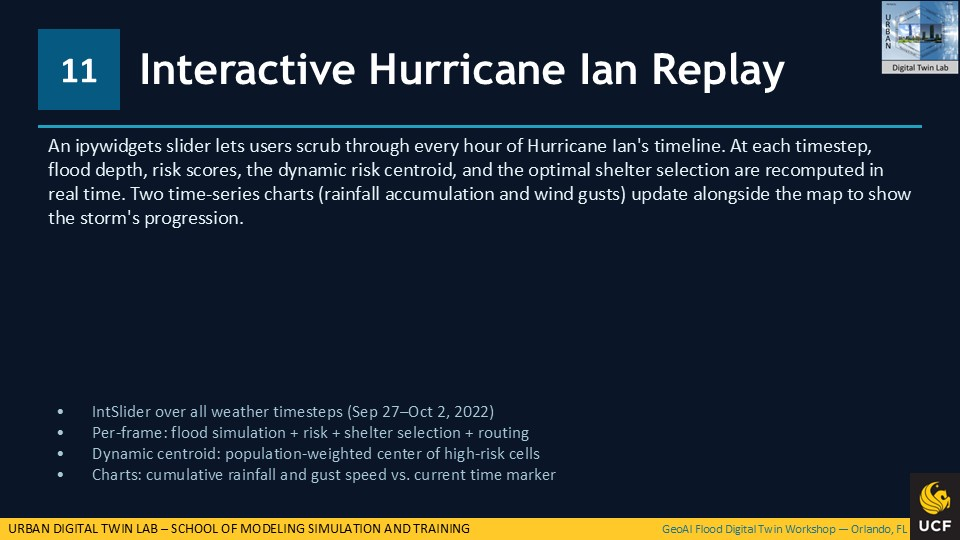

In [ ]:
# ── Slider widget ─────────────────────────────────────────────────────────────
time_slider = widgets.IntSlider(
    min=0,
    max=len(weather_df) - 1,
    step=1,
    value=int(len(weather_df) * 0.45),
    description="🌪️ Ian hour",
    continuous_update=False,
    style={"description_width": "90px"},
    layout=widgets.Layout(width="70%")
)

out_map = widgets.Output()
out_charts = widgets.Output()

def replay_ian(change=None):
    t = time_slider.value
    row = weather_df.iloc[t]

    P_mm = float(row["cumulative_rain_mm"])
    wind = float(row["wind_factor"])
    drainage = float(row["drainage_impairment"])

    flood_surface = simulate_dynamic_flood(P_mm, wind, drainage)
    dynamic_class = classify_flood(flood_surface.ravel())

    flood_norm_t = flood_surface.ravel() / (flood_surface.max() + 1e-9)
    pop_norm_t = grid_gdf["population"].values.astype(float) / (grid_gdf["population"].max() + 1e-9)
    lw_t = grid_gdf["landuse"].map({0: 0.6, 1: 0.8, 2: 1.0, 3: 1.2, 4: 0.4}).values.astype(float)
    lf_t = grid_gdf["lowland_factor"].values.astype(float)

    dynamic_risk = np.clip(
        100 * (
            0.60 * flood_norm_t +
            0.20 * pop_norm_t +
            0.12 * lf_t +
            0.08 * lw_t / 1.2
        ),
        0,
        100
    )

    # Dynamic risk centroid: population-weighted center of high-risk cells (same method as Cell 21)
    high_mask_t = dynamic_risk >= grid_gdf["risk_score"].quantile(0.90) if False else dynamic_risk >= 35
    if high_mask_t.sum() >= 3:
        weights_t = grid_gdf["population"].values[high_mask_t].astype(float)
        weights_t = weights_t if weights_t.sum() > 0 else np.ones_like(weights_t)
        dyn_lat = float(np.average(grid_gdf["lat"].values[high_mask_t], weights=weights_t))
        dyn_lon = float(np.average(grid_gdf["lon"].values[high_mask_t], weights=weights_t))
    else:
        # No elevated risk yet — fall back to peak-hour centroid
        dyn_lat, dyn_lon = risk_centroid_lat, risk_centroid_lon

    # Pre-select shelter, then compute flood-aware route from centroid to it
    pre_selected, _, _, _ = choose_dynamic_shelter_or_exit(flood_surface)
    dyn_route = compute_dynamic_route(
        flood_surface, dyn_lat, dyn_lon,
        float(pre_selected["lat"]), float(pre_selected["lon"])
    )

    with out_map:
        clear_output(wait=True)

        m2, selected_target, shelter_status, shelter_mode, decision_type = build_replay_map(
                    flood_surface, row, dynamic_class, dynamic_risk,
                    dyn_centroid=(dyn_lat, dyn_lon),
                    dyn_route=dyn_route,
                )

        display(m2)

        n_major = int((dynamic_class >= 3).sum())
        n_crit = int((dynamic_risk >= 50).sum())
        pop_at_risk = int(grid_gdf["population"].values[dynamic_risk >= 35].sum())
        unsafe_shelters = int(
            ((shelter_status["is_evac_zone"] == False) & (shelter_status["is_safe"] == False)).sum()
        )

        stats = {
            "☔ Cum. rain": f"{row['cumulative_rain_in']:.2f} in",
            "💧 Rate": f"{row['rain_in']:.2f} in/hr",
            "💨 Gust": f"{row['gust_mph']:.1f} mph",
            "🌊 Major+ cells": str(n_major),
            "🔴 Critical risk": str(n_crit),
            "👥 Pop at risk": f"{pop_at_risk:,}",
            "🎯 Target": selected_target["name"],
            "⚠️ Unsafe shelters": str(unsafe_shelters),
        }

        row_html = "".join(
            f'<td style="padding:7px 12px;border-right:1px solid #e0e0e0;text-align:center">'
            f'<div style="font-size:11px;color:#666;font-weight:bold">{k}</div>'
            f'<div style="font-size:15px;font-weight:bold;color:#1e5f9e">{v}</div></td>'
            for k, v in stats.items()
        )

        display(HTML(
            f'<table style="border-collapse:collapse;background:#f8f9fa;"'
            f'border-radius:8px;overflow:hidden;margin:8px 0">'
            f'<tr>{row_html}</tr></table>'
        ))

    with out_charts:
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))
        fig.suptitle("Hurricane Ian — Real Weather Timeline", fontsize=11, fontweight="bold")

        past = weather_df.iloc[:t + 1]

        ax1.fill_between(
            weather_df["time"],
            weather_df["cumulative_rain_in"],
            alpha=0.15,
            color="#1e5f9e"
        )

        ax1.fill_between(
            past["time"],
            past["cumulative_rain_in"],
            alpha=0.5,
            color="#1e5f9e"
        )

        ax1.plot(
            past["time"],
            past["cumulative_rain_in"],
            color="#1e5f9e",
            lw=2
        )

        ax1.axvline(row["time"], color="crimson", lw=1.5, ls="--")
        ax1.set_ylabel("Cumulative rain (in)")
        ax1.set_title("Rainfall accumulation", fontweight="bold")
        ax1.tick_params(axis="x", rotation=30)

        ax2.fill_between(
            weather_df["time"],
            weather_df["gust_mph"],
            alpha=0.12,
            color="#e05c47"
        )

        ax2.plot(
            past["time"],
            past["gust_mph"],
            color="#e05c47",
            lw=2
        )

        ax2.axvline(row["time"], color="crimson", lw=1.5, ls="--", label="Current")
        ax2.set_ylabel("Wind gust (mph)")
        ax2.set_title("Wind gusts", fontweight="bold")
        ax2.tick_params(axis="x", rotation=30)
        ax2.legend(fontsize=9)

        plt.tight_layout()
        plt.show()

time_slider.observe(replay_ian, names="value")

display(widgets.VBox([
    widgets.HTML(
        '<b style="font-size:14px">🌪️ Hurricane Ian GeoAI Replay</b><br>'
        '<span style="font-size:12px;color:#555">Drag slider — flood severity, shelter feasibility, '
        'and evacuation routing update in real time. <b>Route shown is from the population-weighted '
        'centroid of high-risk areas to the optimal shelter</b> — a county EOC planner\'s view.</span>'
    ),
    time_slider,
    out_map,
    out_charts,
]))

replay_ian()


## 12 · What Makes This GeoAI?

This workshop uses GeoAI because spatial data are not just visualized; they are used in prediction and decision support:

1. **Geospatial inputs:** DEM elevation, lowland factor, slope, land use, population, rainfall, wind, drainage.
2. **AI model:** Random Forest predicts flood class from geospatial and weather features.
3. **Spatial decision intelligence:** risk hotspots drive shelter routing.
4. **Digital twin behavior:** weather timeline updates flood state and risk interpretation.

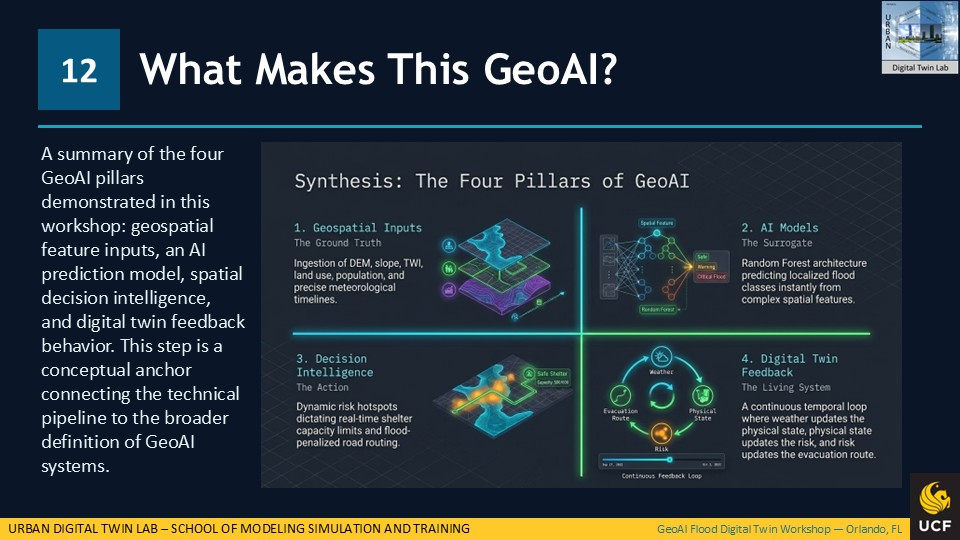

## 13 · Optional Export
Run this only if you want to save the final state.

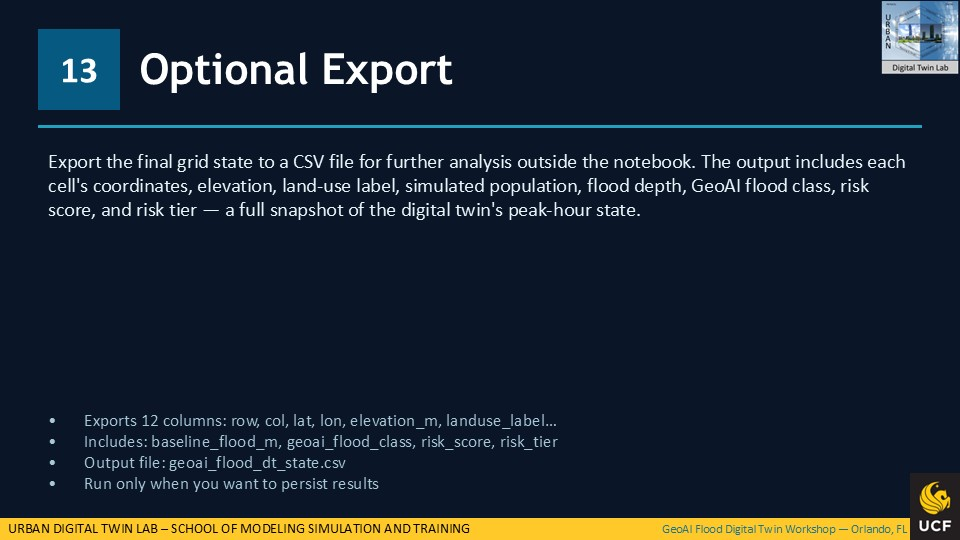

In [ ]:
export_cols = ["row", "col", "lat", "lon", "elevation_m", "landuse_label", "population", "baseline_flood_m", "geoai_flood_class", "geoai_flood_label", "risk_score", "risk_tier"]
export_df = pd.DataFrame(grid_gdf[export_cols])
export_path = "geoai_flood_dt_state.csv"
export_df.to_csv(export_path, index=False)
print(f"✅ Exported: {export_path}")

✅ Exported: geoai_flood_dt_state.csv


## 14 · Discussion Prompts

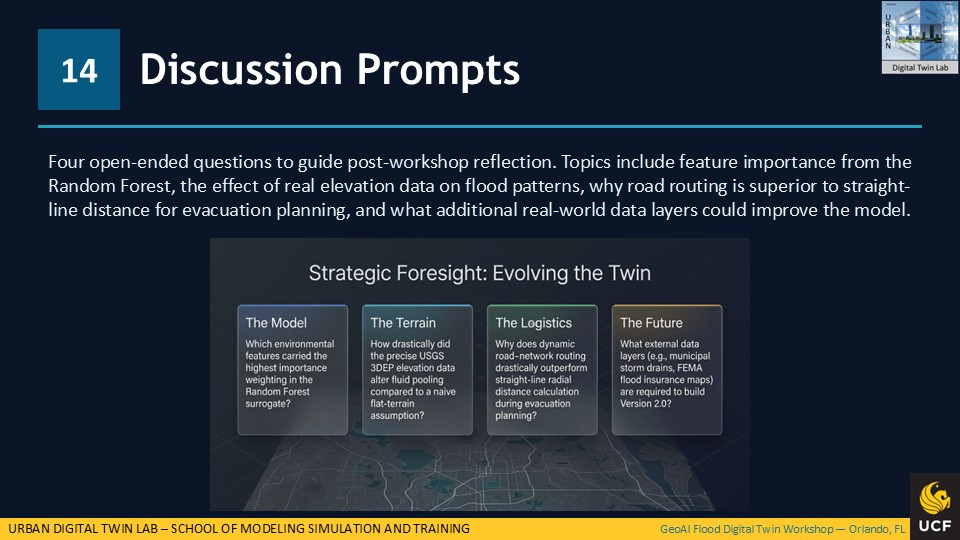